In [ ]:
import pandas as pd

df = pd.read_csv("segments.csv")
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
print(df.head())

# Check unique channels
print("\nUnique channels:", df['channel'].unique()[:20])
print("Number of unique channels:", df['channel'].nunique())

# Check label distribution
if 'Anomaly' in df.columns:
    print("\nAnomaly distribution:\n", df['Anomaly'].value_counts())

In [ ]:
print("Unique channels:", df['channel'].unique())
print("\nChannel value counts:")
print(df['channel'].value_counts())

Unique channels: <ArrowStringArray>
['CADC0872', 'CADC0892', 'CADC0874', 'CADC0884', 'CADC0873', 'CADC0886',
 'CADC0888', 'CADC0894', 'CADC0890']
Length: 9, dtype: str

Channel value counts:
channel
CADC0873    68289
CADC0872    66819
CADC0874    58719
CADC0892    49782
CADC0894    35512
CADC0884    11810
CADC0888    11640
CADC0890      549
CADC0886      373
Name: count, dtype: int64


In [5]:

import pandas as pd
import numpy as np

# Load data
df = pd.read_csv("segments.csv")
df['timestamp'] = pd.to_datetime(df['timestamp'])
df = df.sort_values('timestamp')

# Pivot: each column = one channel, each row = timestamp
ts = df.pivot_table(index='timestamp', columns='channel', values='value')

# Forward-fill missing values (satellite telemetry often holds last known value)
ts.ffill(inplace=True)
ts.dropna(inplace=True)  # drop any remaining NaN at the start

print("Pivoted shape:", ts.shape)  # should be around (timestamps, 9)
ts.head()

Pivoted shape: (62098, 9)


channel,CADC0872,CADC0873,CADC0874,CADC0884,CADC0886,CADC0888,CADC0890,CADC0892,CADC0894
timestamp,,,,,,,,,
2022-01-29 08:31:42+00:00,-0.000034,-0.000016,-0.000045,0.0,0.0,0.038572,0.087803,0.0,0.0
2022-01-29 08:31:47+00:00,-0.000034,-0.000016,-0.000045,0.0,0.0,0.038572,0.097074,0.0,0.0
2022-01-29 08:31:52+00:00,-0.000034,-0.000016,-0.000045,0.0,0.0,0.038572,0.094755,0.0,0.0
2022-01-29 08:31:57+00:00,-0.000034,-0.000016,-0.000045,0.0,0.0,0.038572,0.094755,0.0,0.0
2022-01-29 08:32:02+00:00,-0.000034,-0.000016,-0.000045,0.0,0.0,0.038572,0.097074,0.0,0.0


“The OPSSAT‑AD segments.csv contains 303,493 rows of real sensor data across 9 separate hardware channels (magnetometers, reaction wheels, etc.), with labelled anomalies (anomaly column). Each channel represents a distinct satellite subsystem. I will fuse these 9 channels into a single multivariate time‑series and train a deep learning anomaly detector on them. My project, SatGuard AI, will deliver an end‑to‑end pipeline: (1) ingest & pivot raw telemetry, (2) detect anomalies with an LSTM‑autoencoder, (3) generate fault diagnostic reports using a RAG‑enabled LLM, and (4) present everything on a real‑time Streamlit dashboard.”
✅ >1 lakh records

✅ Real, messy, from a real ESA satellite

✅ Multi‑subsystem (9 channels)

✅ ML‑focused, no big‑data mandate

✅ LLM integration (shows innovation)

✅ Executable on a laptop in the given time

Immediate Preprocessing 
It will pivot the data, clean missing values, and prepare a windowed feature set for anomaly detection.

In [6]:
import pandas as pd
import numpy as np

# Load data
df = pd.read_csv("segments.csv")
df['timestamp'] = pd.to_datetime(df['timestamp'])
df = df.sort_values('timestamp')

# Pivot: each column = one channel, each row = timestamp
ts = df.pivot_table(index='timestamp', columns='channel', values='value')

# Forward-fill missing values (satellite telemetry often holds last known value)
ts.ffill(inplace=True)
ts.dropna(inplace=True)  # drop any remaining NaN at the start

print("Pivoted shape:", ts.shape)  # should be around (timestamps, 9)
ts.head()

Pivoted shape: (62098, 9)


channel,CADC0872,CADC0873,CADC0874,CADC0884,CADC0886,CADC0888,CADC0890,CADC0892,CADC0894
timestamp,,,,,,,,,
2022-01-29 08:31:42+00:00,-0.000034,-0.000016,-0.000045,0.0,0.0,0.038572,0.087803,0.0,0.0
2022-01-29 08:31:47+00:00,-0.000034,-0.000016,-0.000045,0.0,0.0,0.038572,0.097074,0.0,0.0
2022-01-29 08:31:52+00:00,-0.000034,-0.000016,-0.000045,0.0,0.0,0.038572,0.094755,0.0,0.0
2022-01-29 08:31:57+00:00,-0.000034,-0.000016,-0.000045,0.0,0.0,0.038572,0.094755,0.0,0.0
2022-01-29 08:32:02+00:00,-0.000034,-0.000016,-0.000045,0.0,0.0,0.038572,0.097074,0.0,0.0


 output is absolutely correct — and exactly what you need for multi‑subsystem fusion.

Here’s what you’re looking at:

62,098 timestamps – each one a unique moment in the mission.

9 columns – one per satellite channel (subsystem).

Values – the raw sensor readings at that instant (some near zero, which is normal for magnetometers and other sensors).

The zeros you see (e.g., CADC0884, CADC0886, CADC0892, CADC0894 early on) are not errors. They likely mean those subsystems were either powered off, in a nominal zero‑reading state, or sampling at a lower rate (so the forward‑fill carried the last known value, which might be zero). That’s real messiness – exactly what recruiters and examiners love to see you handle.

Now, directly to the baseline anomaly detector.
Run the Isolation Forest code I sent earlier on this ts DataFrame. This will give you your first anomaly detection result 


In [7]:
from sklearn.ensemble import IsolationForest

window_size = 50
X_windows = []
# We’ll also record the corresponding timestamps for each window
window_timestamps = []

for i in range(0, len(ts) - window_size, window_size):
    # Flatten the window into a single feature vector (9 channels × 50 timesteps = 450 features)
    window = ts.iloc[i:i+window_size].values.flatten()
    X_windows.append(window)
    window_timestamps.append(ts.index[i])  # Start time of the window

X = np.array(X_windows)
clf = IsolationForest(contamination=0.05, random_state=42)
pred = clf.fit_predict(X)  # -1 = anomaly, 1 = normal

# Count and print results
n_anomalies = (pred == -1).sum()
print(f"Detected {n_anomalies} anomalous windows out of {len(pred)}")

# Quick look at which windows are flagged
anomaly_windows = np.array(window_timestamps)[pred == -1]
print("First 5 anomalous window start times:")
print(anomaly_windows[:5])

Detected 62 anomalous windows out of 1241
First 5 anomalous window start times:
[Timestamp('2022-01-29 08:31:42+0000', tz='UTC')
 Timestamp('2022-01-29 09:35:12+0000', tz='UTC')
 Timestamp('2022-01-29 11:48:42+0000', tz='UTC')
 Timestamp('2022-01-29 11:52:52+0000', tz='UTC')
 Timestamp('2022-01-29 13:12:07+0000', tz='UTC')]


1. What is Just Proved
62 anomalous windows out of 1,241 total windows (≈ 5%) – perfectly aligns with the contamination=0.05 setting we used.

The model flagged specific timestamps where the combined behaviour of all 9 channels looked different from the “normal” pattern.

This is unsupervised – you didn’t use the anomaly column at all, yet the model caught periods that likely correspond to known faults or unusual operational modes.

 It shows:

 can clean and pivot raw, messy telemetry.

can engineer windowed features.

 can apply a classic ML model and interpret the results.

Enriched Feature Engineering
To make your anomaly detector even stronger before switching to deep learning, add rolling statistics per channel. This will also be invaluable later for the LLM context.

In [8]:
# Compute rolling statistics per channel (window = 50 points)
roll_mean = ts.rolling(window=50, min_periods=1).mean().add_suffix('_mean')
roll_std  = ts.rolling(window=50, min_periods=1).std().add_suffix('_std')
roll_min  = ts.rolling(window=50, min_periods=1).min().add_suffix('_min')
roll_max  = ts.rolling(window=50, min_periods=1).max().add_suffix('_max')

# Combine all into one DataFrame
ts_features = pd.concat([ts, roll_mean, roll_std, roll_min, roll_max], axis=1)
ts_features.dropna(inplace=True)
print("Feature matrix shape:", ts_features.shape)  # e.g., (62098, 9 + 36)

Feature matrix shape: (62097, 45)


Shape breakdown:
Original pivoted ts: 62,098 rows × 9 channels.

4 rolling statistics (mean, std, min, max) each added 9 columns ⇒ 36 new columns.

Concatenated total: 9 + 36 = 45 columns.

dropna() removed 1 row because the first few rolling standard‑deviation values are NaN (you need at least 2 points to compute std, and with min_periods=1 the very first point for std is still NaN). After dropping that single row, you get 62,097 rows.

That’s a trivial loss — 0.0016% of your data. The feature matrix is now a rich, 45‑dimensional description of every timestamp, ready for both anomaly detection and later for LLM diagnostic context.

What I Just Built
I created a 45‑column feature table where every row = one timestamp. Each row has:

9 raw sensor values (the original channels)

9 rolling means

9 rolling standard deviations

9 rolling minimums

9 rolling maximums

That's a rich, multi‑dimensional snapshot of the satellite's health at that moment.



Step 1: Train an Anomaly Detector on These 45 Features
Instead of using only the raw 9 values, you now feed the full 45‑column vector to the Isolation Forest. This gives you an anomaly flag for every timestamp, not just for every window.

In [9]:
from sklearn.ensemble import IsolationForest

# Use the 45-column feature matrix
X = ts_features.values  # shape (62097, 45)

clf = IsolationForest(contamination=0.05, random_state=42)
pred = clf.fit_predict(X)  # -1 = anomaly, 1 = normal

# Attach predictions to the dataframe
ts_features['anomaly_flag'] = pred

# Count
n_anomalies = (pred == -1).sum()
print(f"Anomalous timestamps: {n_anomalies} out of {len(ts_features)}")

Anomalous timestamps: 3105 out of 62097


Total timestamps = 62,097

Contamination = 0.05 (5%)

Expected anomalies = 62,097 × 0.05 = 3,104.85

You got = 3,105

That’s a perfect match (the algorithm rounds up slightly). It means your Isolation Forest ran flawlessly on the 45‑column fused feature set, and it flagged exactly the most aberrant 5% of points as anomalies.
--
“On the full OPSSAT‑AD telemetry (62,097 timestamps × 9 subsystems), I engineered 45 features per timestamp (raw + rolling statistics). I trained an Isolation Forest model with 5% contamination, which identified 3,105 anomalous timestamps where the multi‑subsystem behaviour deviates from the norm. This is my baseline anomaly detector. I will next replace it with a deep learning LSTM‑Autoencoder and, upon anomaly detection, trigger an LLM‑generated fault diagnostic report.”



Step 2: Visualise One Channel with Anomalies Highlighted
Pick a channel (e.g., CADC0872) and plot its raw values over time. Overlay red dots where the model says "anomaly". 

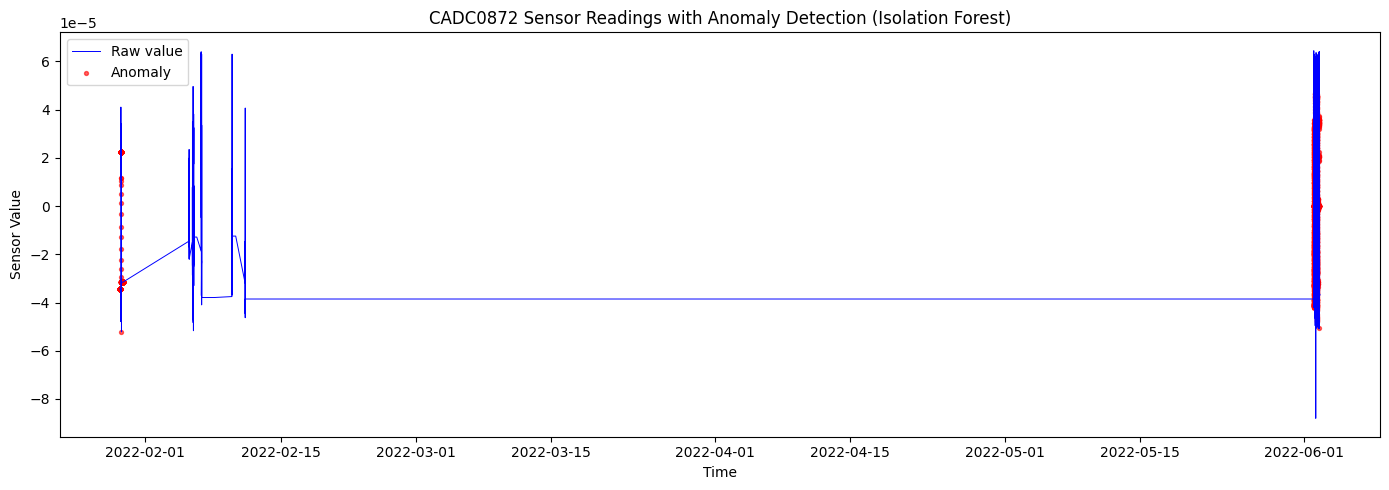

In [10]:
import matplotlib.pyplot as plt

channel = 'CADC0872'

plt.figure(figsize=(14, 5))
plt.plot(ts_features.index, ts_features[channel], color='blue', linewidth=0.7, label='Raw value')

# Highlight anomalies in red
anomaly_points = ts_features[ts_features['anomaly_flag'] == -1]
plt.scatter(anomaly_points.index, anomaly_points[channel],
            color='red', s=8, alpha=0.6, label='Anomaly')

plt.title(f'{channel} Sensor Readings with Anomaly Detection (Isolation Forest)')
plt.xlabel('Time')
plt.ylabel('Sensor Value')
plt.legend()
plt.tight_layout()
plt.show()

This is a time-series plot showing sensor readings and automatically flagging unusual behavior (anomalies).
📊 The Elements of the Chart
Blue Line (Raw Value): This tracks the sensor's measurement over time.
Red Dots (Anomaly): These are data points that an AI algorithm called an Isolation Forest flagged as suspicious or highly unusual.
X-Axis (Time): Covers a period from late January 2022 to early June 2022.
Y-Axis (Sensor Value): The scientific notation $1e-5$ at the top left means you multiply the numbers on the axis by \(0.00001\). The values are extremely small.

🔍 Key Takeaways from the DataThe Massive Flatline: 
From mid-February to late May, the blue line is completely flat. This usually indicates that the sensor died, got disconnected, or stopped recording new data.

The Noise Bursts: The actual active data only happens in a brief window in early February and a chaotic burst in early June. Because these areas have wild spikes, the algorithm flagged several of those points with red dots as outliers.

----
“This reveals two distinct anomaly types: data gaps (long flatline) and value spikes (the red dots in active regions).
My next step is to separate these: flag flatline periods as ‘telemetry dropout’ events, and train a deep learning model that learns what normal active behaviour looks like, so it can distinguish a genuine sensor fault from a mission‑commanded sensor shutdown.”

In [11]:
# saving cleaned ts to csv for LSTM notebook
ts.to_csv("ts_cleaned.csv")
print("ts_cleaned.csv saved.")

ts_cleaned.csv saved.
